In [24]:
# Zelle 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error

training_data = pd.read_csv("train.csv")
testing_data = pd.read_csv("test.csv")

train_indexed = training_data.set_index("Id")
y_full = train_indexed["SalePrice"]
X_full_raw = train_indexed.drop(columns="SalePrice")

X_train_raw, X_holdout_raw, y_train, y_holdout = train_test_split(
    X_full_raw, y_full, test_size=0.2, random_state=123
)

cv = KFold(n_splits=5, shuffle=True, random_state=123)

y_train_log = np.log1p(y_train)
y_holdout_log = np.log1p(y_holdout)

In [2]:
# Zelle 2
def add_features(df):
    df = df.copy()

    df["MSSubClass"] = df["MSSubClass"].astype("string")
    df["Functional"] = df["Functional"].fillna("Typ")
    df["KitchenQual"] = df["KitchenQual"].fillna("TA")
    df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

    df["HasGarage"] = (
        (df["GarageArea"].fillna(0) > 0)
        | (df["GarageCars"].fillna(0) > 0)
        | df["GarageType"].notna()
    ).astype(int)
    df["HasBasement"]  = (df["TotalBsmtSF"].fillna(0) > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"].fillna(0) > 0).astype(int)
    df["HasPool"]      = (df["PoolArea"].fillna(0) > 0).astype(int)
    has_masonry_type = df["MasVnrType"].notna() & df["MasVnrType"].ne("None")
    df["HasMasonry"] = (has_masonry_type | df["MasVnrArea"].fillna(0).gt(0)).astype(int)
    df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
    df["LotFrontageMissing"] = df["LotFrontage"].isna().astype(int)

    df["HouseAge"]          = df["YrSold"] - df["YearBuilt"]
    df["YearsSinceRemodel"] = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)
    df["TotalSF"]           = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBathrooms"]    = df["FullBath"] + 0.5*df["HalfBath"] + df["BsmtFullBath"].fillna(0) + 0.5*df["BsmtHalfBath"].fillna(0)

    return df

In [3]:
# Zelle 3
ordinal_categories = {
    "ExterQual":   ["None","Po","Fa","TA","Gd","Ex"],
    "ExterCond":   ["None","Po","Fa","TA","Gd","Ex"],
    "BsmtQual":    ["None","Po","Fa","TA","Gd","Ex"],
    "BsmtCond":    ["None","Po","Fa","TA","Gd","Ex"],
    "HeatingQC":   ["None","Po","Fa","TA","Gd","Ex"],
    "KitchenQual": ["Po","Fa","TA","Gd","Ex"],
    "FireplaceQu": ["None","Po","Fa","TA","Gd","Ex"],
    "GarageQual":  ["None","Po","Fa","TA","Gd","Ex"],
    "GarageCond":  ["None","Po","Fa","TA","Gd","Ex"],
    "PoolQC":      ["None","Po","Fa","TA","Gd","Ex"],
    "BsmtExposure":["None","No","Mn","Av","Gd"],
    "BsmtFinType1":["None","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],
    "BsmtFinType2":["None","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],
    "PavedDrive":  ["N","P","Y"],
    "LandSlope":   ["Sev","Mod","Gtl"],
    "GarageFinish":["None","Unf","RFn","Fin"],
    "Functional":  ["Sal","Sev","Maj2","Maj1","Mod","Min2","Min1","Typ"],
    "Fence":       ["None","MnWw","GdWo","MnPrv","GdPrv"],
}
ordinal_features = list(ordinal_categories.keys())

ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OrdinalEncoder(categories=list(ordinal_categories.values()), handle_unknown="use_encoded_value", unknown_value=-1))
])

In [4]:
# Zelle 4
X_train = add_features(X_train_raw)
X_holdout = add_features(X_holdout_raw)

num_features = X_train.select_dtypes(include="number").columns
cat_features = X_train.select_dtypes(exclude="number").columns
nominal_features = [c for c in cat_features if c not in ordinal_features]

print("Anzahl numerisch:", len(num_features), "| ordinal:", len(ordinal_features), "| nominal:", len(nominal_features))

Anzahl numerisch: 45 | ordinal: 18 | nominal: 26


In [5]:
# Zelle 5 — Preprocessor für Bäume (unskaliert, dichte One-Hot-Matrix)
tree_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), num_features),
    ("ordinal", ord_pipe, ordinal_features),
    ("nominal", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="N_A")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), nominal_features),
])



In [6]:
# Zelle 6 — Preprocessor für lineare Modelle (skaliert)
linear_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]), num_features),
    ("ordinal", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
        ("encoder", OrdinalEncoder(categories=list(ordinal_categories.values()), handle_unknown="use_encoded_value", unknown_value=-1)),
        ("scaler", RobustScaler())
    ]), ordinal_features),
    ("nominal", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="N_A")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), nominal_features),
])

In [7]:
# Zelle 7 — Modellvergleich, drei Kandidaten
models = {
    "Lasso": Pipeline([("preprocessor", linear_preprocessor), ("regressor", Lasso(alpha=0.001, max_iter=50000))]),
    "HistGB": Pipeline([("preprocessor", tree_preprocessor), ("regressor", HistGradientBoostingRegressor(random_state=123))]),
    "RandomForest": Pipeline([("preprocessor", tree_preprocessor), ("regressor", RandomForestRegressor(random_state=123))]),
}

results = {}
for name, pipe in models.items():
    scores = -cross_val_score(pipe, X_train, y_train_log, cv=cv, scoring="neg_root_mean_squared_error")
    results[name] = scores
    print(f"{name}: RMSLE {scores.mean():.4f} ± {scores.std():.4f}")

Lasso: RMSLE 0.1495 ± 0.0315
HistGB: RMSLE 0.1414 ± 0.0097
RandomForest: RMSLE 0.1497 ± 0.0043


In [8]:
# Zelle 8 — Fold-für-Fold-Blick auf Lasso, um die hohe Streuung einzuordnen
lasso_pipe = models["Lasso"]
for i, (train_idx, val_idx) in enumerate(cv.split(X_train)):
    lasso_pipe.fit(X_train.iloc[train_idx], y_train_log.iloc[train_idx])
    pred = lasso_pipe.predict(X_train.iloc[val_idx])
    fold_rmsle = np.sqrt(np.mean((y_train_log.iloc[val_idx] - pred) ** 2))
    val_ids = X_train.iloc[val_idx].index
    outliers_in_fold = [oid for oid in [524, 1299] if oid in val_ids]
    print(f"Fold {i}: RMSLE {fold_rmsle:.4f}, Ausreißer im Val-Set: {outliers_in_fold}")

Fold 0: RMSLE 0.2113, Ausreißer im Val-Set: [1299]
Fold 1: RMSLE 0.1323, Ausreißer im Val-Set: []
Fold 2: RMSLE 0.1316, Ausreißer im Val-Set: []
Fold 3: RMSLE 0.1458, Ausreißer im Val-Set: [524]
Fold 4: RMSLE 0.1266, Ausreißer im Val-Set: []


In [ ]:
# Zelle 9 - Outlier-Ablation, mit dem manuellen, gepaarten CV-Loop
outlier_ids = [524, 1299]

def rmsle_cv_drop(pipe, X, y, cv, drop_ids):
    scores = []
    for train_idx, val_idx in cv.split(X):
        train_ids = X.index[train_idx].difference(drop_ids)  # Ausreißer nur aus dem Trainingsanteil
        val_ids = X.index[val_idx]                             # Val-Anteil bleibt unverändert, gleiche Folds wie die Baseline

        pipe.fit(X.loc[train_ids], y.loc[train_ids])
        pred = pipe.predict(X.loc[val_ids])
        scores.append(np.sqrt(np.mean((y.loc[val_ids] - pred) ** 2)))
    return np.array(scores)

lasso_dropped_scores = rmsle_cv_drop(models["Lasso"], X_train, y_train_log, cv, outlier_ids)
lasso_baseline_scores = results["Lasso"]

diff = lasso_baseline_scores - lasso_dropped_scores  # positiv = Drop war besser (kleinerer Fehler)
print("Lasso mit Drop:", lasso_dropped_scores.mean(), "±", lasso_dropped_scores.std())
print("Lasso ohne Drop (Baseline):", lasso_baseline_scores.mean(), "±", lasso_baseline_scores.std())
print("Δ (Baseline − Drop):", diff.mean(), "| positive Folds:", (diff > 0).sum(), "/", len(diff))

Lasso mit Drop: 0.147778035914428 ± 0.0420085924865046
Lasso ohne Drop (Baseline): 0.14954984415836106 ± 0.03154010891042596
Δ (Baseline − Drop): 0.0017718082439330512 | positive Folds: 3 / 5


In [10]:
# Zelle 10 — Prüfen, ob test.csv ähnlich extreme GrLivArea-Werte enthält
print("Train, GrLivArea > 4000:", (X_full_raw["GrLivArea"] > 4000).sum())
print("Test, GrLivArea > 4000:", (testing_data["GrLivArea"] > 4000).sum())
print(testing_data.loc[testing_data["GrLivArea"] > 4000, ["Id", "GrLivArea", "OverallQual"]])

Train, GrLivArea > 4000: 4
Test, GrLivArea > 4000: 1
        Id  GrLivArea  OverallQual
1089  2550       5095           10


In [11]:
# Zelle 11 — Explorativ: Lasso-Stabilität ohne die zwei Ausreißer (andere Folds, nicht gepaart!)
keep = ~X_train.index.isin(outlier_ids)
X_clean, y_clean = X_train.loc[keep], y_train_log.loc[keep]

for name, pipe in models.items():
    scores = -cross_val_score(pipe, X_clean, y_clean, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name} ohne 524/1299: {scores.mean():.4f} ± {scores.std():.4f}")

Lasso ohne 524/1299: 0.1159 ± 0.0164
HistGB ohne 524/1299: 0.1287 ± 0.0192
RandomForest ohne 524/1299: 0.1396 ± 0.0181


In [12]:
# Zelle 12 — Vergleich aller vier großen Trainingshäuser mit dem einen großen Testhaus
big_train = X_full_raw[X_full_raw["GrLivArea"] > 4000][["GrLivArea", "OverallQual", "SaleCondition", "Neighborhood", "YearBuilt"]].copy()
big_train["SalePrice"] = y_full.loc[big_train.index]
print("Große Häuser im Training:")
print(big_train)

print("\nDas eine große Haus im Test:")
print(testing_data.loc[testing_data["GrLivArea"] > 4000, ["Id","GrLivArea","OverallQual","SaleCondition","Neighborhood","YearBuilt"]])

Große Häuser im Training:
      GrLivArea  OverallQual SaleCondition Neighborhood  YearBuilt  SalePrice
Id                                                                           
524        4676           10       Partial      Edwards       2007     184750
692        4316           10        Normal      NoRidge       1994     755000
1183       4476           10       Abnorml      NoRidge       1996     745000
1299       5642           10       Partial      Edwards       2008     160000

Das eine große Haus im Test:
        Id  GrLivArea  OverallQual SaleCondition Neighborhood  YearBuilt
1089  2550       5095           10       Partial      Edwards       2008


In [13]:
# Zelle 13 — gepaarter Modellvergleich auf den vollen 1168 Trainingszeilen, Gate 0,003 / 4-5
comparisons = [
    ("HistGB − Lasso", results["HistGB"] - results["Lasso"]),
    ("HistGB − RandomForest", results["HistGB"] - results["RandomForest"]),
    ("Lasso − RandomForest", results["Lasso"] - results["RandomForest"]),
]
for name, diff in comparisons:
    print(f"{name}: Δ={diff.mean():.4f} | positive Folds: {(diff < 0).sum()}/{len(diff)}")
    # Achtung: diff = A - B, bei RMSLE ist NIEDRIGER besser, also zählt "A besser als B" als diff < 0

HistGB − Lasso: Δ=-0.0082 | positive Folds: 2/5
HistGB − RandomForest: Δ=-0.0083 | positive Folds: 4/5
Lasso − RandomForest: Δ=-0.0001 | positive Folds: 3/5


In [14]:
# Zelle 14 — Beide Finalisten tunen, gleiche cv, log-Ziel
from sklearn.model_selection import GridSearchCV

lasso_grid = {
    "regressor__alpha": [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
}
lasso_search = GridSearchCV(models["Lasso"], lasso_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
lasso_search.fit(X_train, y_train_log)
print("Lasso best:", lasso_search.best_params_, -lasso_search.best_score_)

histgb_grid = {
    "regressor__max_leaf_nodes": [15, 31, 63],
    "regressor__learning_rate": [0.02, 0.05, 0.1],
    "regressor__max_iter": [200, 400],
    "regressor__min_samples_leaf": [10, 20, 30],
}
histgb_search = GridSearchCV(models["HistGB"], histgb_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
histgb_search.fit(X_train, y_train_log)
print("HistGB best:", histgb_search.best_params_, -histgb_search.best_score_)

Lasso best: {'regressor__alpha': 0.001} 0.14954984415836106
HistGB best: {'regressor__learning_rate': 0.1, 'regressor__max_iter': 200, 'regressor__max_leaf_nodes': 15, 'regressor__min_samples_leaf': 10} 0.13654885364599129


In [15]:
# Zelle 15 — erweitertes Gitter, diesmal als RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

histgb_grid_v2 = {
    "regressor__max_leaf_nodes": [5, 7, 10, 15, 21],
    "regressor__learning_rate": [0.05, 0.1, 0.15, 0.2, 0.3],
    "regressor__max_iter": [100, 150, 200, 300],
    "regressor__min_samples_leaf": [3, 5, 10, 15],
}

histgb_search_v2 = RandomizedSearchCV(
    models["HistGB"], histgb_grid_v2, n_iter=40, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1, random_state=123
)
histgb_search_v2.fit(X_train, y_train_log)
print("HistGB v2 best:", histgb_search_v2.best_params_, -histgb_search_v2.best_score_)

HistGB v2 best: {'regressor__min_samples_leaf': 3, 'regressor__max_leaf_nodes': 10, 'regressor__max_iter': 200, 'regressor__learning_rate': 0.05} 0.13345707009199975


In [16]:
# Zelle 16
tuned_v2 = -cross_val_score(histgb_search_v2.best_estimator_, X_train, y_train_log, cv=cv,
                             scoring="neg_root_mean_squared_error")
base = results["HistGB"]
diff = base - tuned_v2
print("Getunt (v2):", tuned_v2.mean(), "±", tuned_v2.std())
print("Δ vs. ungetunt:", diff.mean(), "| positive Folds:", (diff > 0).sum(), "/", len(diff))

Getunt (v2): 0.13345707009199975 ± 0.007517354014063582
Δ vs. ungetunt: 0.007936600300533253 | positive Folds: 4 / 5


In [17]:
# Zelle 17
from sklearn.base import clone

finalists = {
    "Lasso": models["Lasso"],
    "HistGB untuned": models["HistGB"],
    "HistGB tuned (v1)": histgb_search.best_estimator_,
    "HistGB tuned (v2)": histgb_search_v2.best_estimator_,
}

for name, model in finalists.items():
    fitted = clone(model).fit(X_train, y_train_log)
    prediction = fitted.predict(X_holdout)
    rmsle = np.sqrt(np.mean((y_holdout_log - prediction) ** 2))
    print(f"{name}: Holdout RMSLE {rmsle:.4f}")

Lasso: Holdout RMSLE 0.1025
HistGB untuned: Holdout RMSLE 0.1158
HistGB tuned (v1): Holdout RMSLE 0.1156
HistGB tuned (v2): Holdout RMSLE 0.1088


In [18]:
# Zelle 18 — Fehleranalyse auf dem Holdout, Lasso vs. HistGB(v2)
lasso_fitted = clone(models["Lasso"]).fit(X_train, y_train_log)
histgb_fitted = clone(histgb_search_v2.best_estimator_).fit(X_train, y_train_log)

pred_lasso = lasso_fitted.predict(X_holdout)
pred_histgb = histgb_fitted.predict(X_holdout)

errors = X_holdout.copy()
errors["SalePrice_true"] = y_holdout
errors["Lasso_pred"] = np.expm1(pred_lasso).round(0)
errors["HistGB_pred"] = np.expm1(pred_histgb).round(0)
errors["Lasso_error"] = (errors["Lasso_pred"] - errors["SalePrice_true"]).abs()
errors["HistGB_error"] = (errors["HistGB_pred"] - errors["SalePrice_true"]).abs()
errors["diff"] = errors["HistGB_error"] - errors["Lasso_error"]  # positiv = Lasso war hier besser

print("HistGB schlechter als Lasso bei", (errors["diff"] > 0).sum(), "von", len(errors), "Häusern")
display_cols = ["SalePrice_true", "Lasso_pred", "HistGB_pred", "GrLivArea", "OverallQual", "Neighborhood"]
errors.sort_values("diff", ascending=False)[display_cols].head(10)

HistGB schlechter als Lasso bei 142 von 292 Häusern


,SalePrice_true,Lasso_pred,HistGB_pred,GrLivArea,OverallQual,Neighborhood
Id,,,,,,
168,325624,323246.0,386632.0,2161,8,NridgHt
262,276000,292204.0,350102.0,2574,8,CollgCr
333,284000,286131.0,343908.0,1629,8,NridgHt
1214,145000,138868.0,109610.0,960,4,Sawyer
1360,315000,364267.0,392545.0,1980,9,NridgHt
170,228000,222771.0,260310.0,1707,8,Timber
804,582933,437489.0,413421.0,2822,9,NridgHt
935,242000,249427.0,210803.0,2069,7,NAmes
219,311500,243872.0,220716.0,1954,7,Crawfor


In [19]:
# Zelle 19 — OOF-Blend-Test, mit der korrigierten, gepaarten Auswertung gegen tuned_v2 aus Zelle 16
from sklearn.model_selection import cross_val_predict

oof_lasso = cross_val_predict(models["Lasso"], X_train, y_train_log, cv=cv)
oof_histgb = cross_val_predict(histgb_search_v2.best_estimator_, X_train, y_train_log, cv=cv)

fold_indices = list(cv.split(X_train))

for w in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0]:
    blend = w * oof_histgb + (1 - w) * oof_lasso
    fold_scores = np.array([
        np.sqrt(np.mean((y_train_log.iloc[va] - blend[va]) ** 2))
        for _, va in fold_indices
    ])
    diff = tuned_v2 - fold_scores  # positiv = Blend besser als reines HistGB v2
    print(f"w_hist={w:.1f}: RMSLE {fold_scores.mean():.4f} ± {fold_scores.std():.4f} | Δ vs. HistGB v2: {diff.mean():.4f} | positive Folds: {(diff > 0).sum()}/5")

w_hist=0.0: RMSLE 0.1495 ± 0.0315 | Δ vs. HistGB v2: -0.0161 | positive Folds: 1/5
w_hist=0.2: RMSLE 0.1418 ± 0.0235 | Δ vs. HistGB v2: -0.0084 | positive Folds: 2/5
w_hist=0.3: RMSLE 0.1387 ± 0.0196 | Δ vs. HistGB v2: -0.0052 | positive Folds: 2/5
w_hist=0.4: RMSLE 0.1361 ± 0.0158 | Δ vs. HistGB v2: -0.0026 | positive Folds: 3/5
w_hist=0.5: RMSLE 0.1341 ± 0.0123 | Δ vs. HistGB v2: -0.0006 | positive Folds: 4/5
w_hist=0.6: RMSLE 0.1326 ± 0.0092 | Δ vs. HistGB v2: 0.0008 | positive Folds: 4/5
w_hist=0.7: RMSLE 0.1318 ± 0.0069 | Δ vs. HistGB v2: 0.0016 | positive Folds: 4/5
w_hist=1.0: RMSLE 0.1335 ± 0.0075 | Δ vs. HistGB v2: 0.0000 | positive Folds: 0/5


In [20]:
# Zelle 20 — neuer Zweig für Lasso mit log-transformierten schiefen Features

skewed_features = ["GrLivArea", "LotArea", "1stFlrSF", "TotalSF", "TotalBsmtSF"]
# alle nichtnegativ, alle bekanntermaßen rechtsschief

def add_log_features(df):
    df = df.copy()
    for col in skewed_features:
        df[col] = np.log1p(df[col])
    return df

X_train_logfeat = add_log_features(X_train)
X_holdout_logfeat = add_log_features(X_holdout)

lasso_logfeat_scores = -cross_val_score(models["Lasso"], X_train_logfeat, y_train_log, cv=cv, scoring="neg_root_mean_squared_error")
diff = results["Lasso"] - lasso_logfeat_scores
print("Lasso mit Log-Features:", lasso_logfeat_scores.mean(), "±", lasso_logfeat_scores.std())
print("Δ vs. Standard-Lasso:", diff.mean(), "| positive Folds:", (diff > 0).sum(), "/5")

Lasso mit Log-Features: 0.13509337215718853 ± 0.018135565508743255
Δ vs. Standard-Lasso: 0.014456472001172532 | positive Folds: 5 /5


In [21]:
# Zelle 21 — OOF für die verbesserte Lasso-Version

oof_lasso_logfeat = cross_val_predict(models["Lasso"], X_train_logfeat, y_train_log, cv=cv)
# oof_histgb aus Zelle 19 bereits vorhanden

for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    blend = w * oof_histgb + (1 - w) * oof_lasso_logfeat
    fold_scores = np.array([
        np.sqrt(np.mean((y_train_log.iloc[va] - blend[va]) ** 2))
        for _, va in fold_indices
    ])
    diff = tuned_v2 - fold_scores
    print(f"w_hist={w:.1f}: RMSLE {fold_scores.mean():.4f} ± {fold_scores.std():.4f} | Δ vs. HistGB v2: {diff.mean():.4f} | positive Folds: {(diff > 0).sum()}/5")

w_hist=0.3: RMSLE 0.1294 ± 0.0108 | Δ vs. HistGB v2: 0.0040 | positive Folds: 4/5
w_hist=0.4: RMSLE 0.1285 ± 0.0086 | Δ vs. HistGB v2: 0.0050 | positive Folds: 4/5
w_hist=0.5: RMSLE 0.1280 ± 0.0067 | Δ vs. HistGB v2: 0.0054 | positive Folds: 4/5
w_hist=0.6: RMSLE 0.1281 ± 0.0054 | Δ vs. HistGB v2: 0.0054 | positive Folds: 4/5
w_hist=0.7: RMSLE 0.1287 ± 0.0049 | Δ vs. HistGB v2: 0.0048 | positive Folds: 4/5


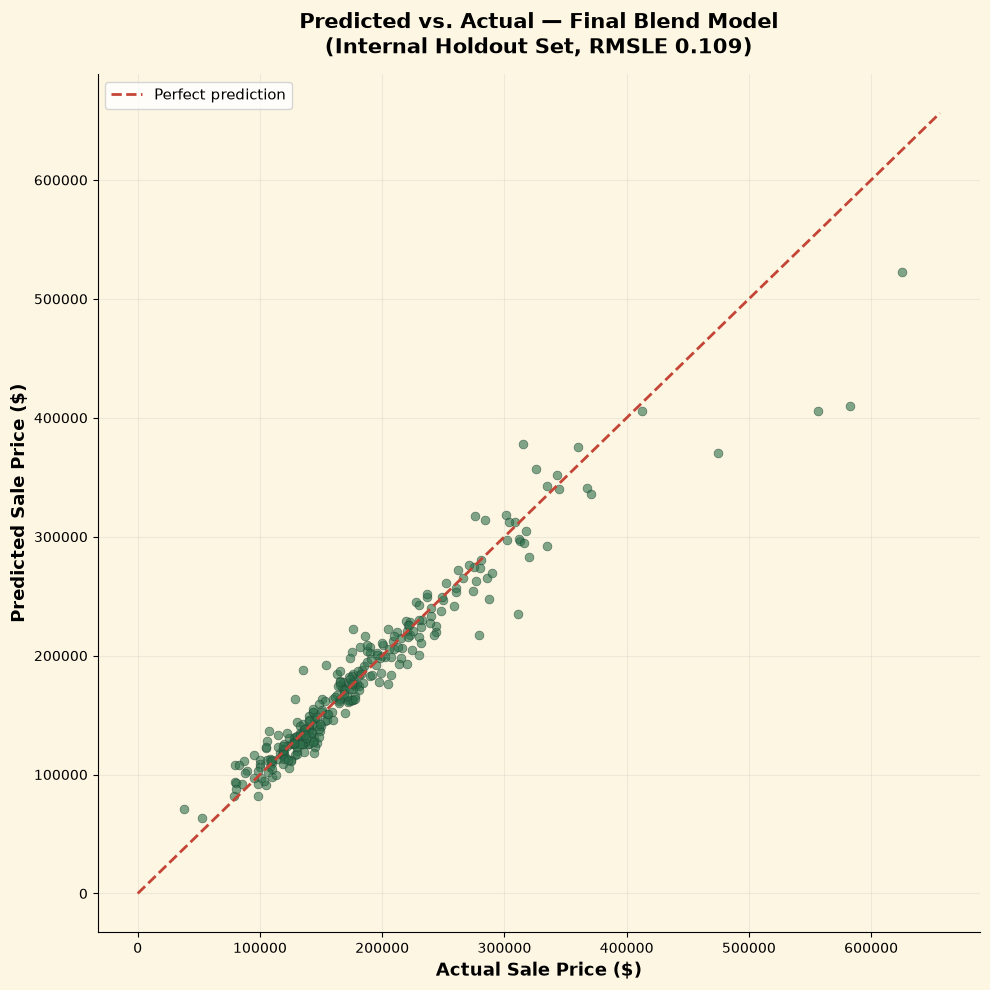

In [ ]:
# Zelle 22 Visualisierung: Predicted vs. Actual (finales Blend-Modell)

fig, ax = plt.subplots(figsize=(10, 10), facecolor="#FDF6E3")  # warmer, heller Hintergrund
ax.set_facecolor("#FDF6E3")

ax.scatter(actual, predicted, alpha=0.6, color="#2C6E49", s=40, edgecolors="#1B4332", linewidths=0.5)

lims = [0, max(actual.max(), predicted.max()) * 1.05]
ax.plot(lims, lims, "--", color="#C44536", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual Sale Price ($)", fontsize=13, fontweight="bold")
ax.set_ylabel("Predicted Sale Price ($)", fontsize=13, fontweight="bold")
ax.set_title("Predicted vs. Actual — Final Blend Model\n(Internal Holdout Set, RMSLE 0.109)", fontsize=15, fontweight="bold", pad=15)

ax.legend(fontsize=11, loc="upper left", frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("blend_predicted_vs_actual_linkedin.png", dpi=200, facecolor="#FDF6E3")
plt.show()